# ImageNet-256 FID trajectories

Discover ImageNet-256 training runs, evaluate checkpoints at a configurable interval, cache FID results, and plot trajectories. Device selection is delegated to the repository accelerator utilities, which prefer Intel XPU on Dawn and retain CUDA/CPU fallbacks.

The expensive sweep is restartable: valid result JSON files are reused by `evaluate_checkpoint_fidutil.py --skip-existing`. For a quick test, use 1,000 samples and one checkpoint; restore 50,000 samples for reportable FID.

In [1]:
from __future__ import annotations

import json, math, os, re, shutil, subprocess, sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

here = Path.cwd().resolve()
REPO = next((p for p in (here, *here.parents) if (p / 'evaluate_checkpoint_fidutil.py').is_file()), None)
if REPO is None:
    raise FileNotFoundError('Start Jupyter inside the riesz_flow_hudson repository')
sys.path.insert(0, str(REPO))
from utils.dist_util import accelerator_type, local_device_count, xpu_is_available
from utils.env import IMAGENET_FID_NPZ

RDS_ROOT = Path('/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM')
RUNS_ROOT = RDS_ROOT / 'runs'
RESULTS_ROOT = RDS_ROOT / 'artifacts' / 'fid_imagenet256'
SCORE_CSV = REPO / 'notebooks' / 'fid_imagenet256_fid50k_scores.csv'
NODE_TMP = Path(os.environ.get('SLURM_TMPDIR') or os.environ.get('TMPDIR') or '/tmp')
TMP_ROOT = NODE_TMP / f"fid_imagenet256_{os.environ.get('SLURM_JOB_ID', os.getpid())}"
STEP_INTERVAL = 2_000
SKIP_THROUGH_STEP = 5_000  # exclude early checkpoints with poor FID
NUM_SAMPLES = 50_000
CFG_SCALES = '1.19'       # blank => all scales from each training config
GEN_BSZ_PER_DEVICE = 64
NPROC_PER_NODE = 1        # robust single-PVC default on Dawn
SEED = 0
FID_REF = ''              # blank => utils.env.IMAGENET_FID_NPZ
RUN_NAME_REGEX = r'^imagenet256_'
MAX_CHECKPOINTS = None    # e.g. 1 for a smoke test

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
TMP_ROOT.mkdir(parents=True, exist_ok=True)
tmp_free_gib = shutil.disk_usage(TMP_ROOT).free / 1024**3
device_kind = accelerator_type()
print(f'Repository: {REPO}')
print(f'Runs:       {RUNS_ROOT}')
print(f'Results:    {RESULTS_ROOT}')
print(f'Temporary:  {TMP_ROOT} ({tmp_free_gib:.1f} GiB free)')
print(f'Accelerator: {device_kind} ({local_device_count()} visible device(s)); XPU available={xpu_is_available()}')


Repository: /home/rc-chen1/riesz_flow_hudson
Runs:       /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs
Results:    /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet256
Temporary:  /tmp/fid_imagenet256_33928326 (15.8 GiB free)
Accelerator: xpu (2 visible device(s)); XPU available=True


## Discover checkpoints and map runs to model configs

In [2]:
NAMED_CONFIGS = sorted(
    (REPO / 'configs/gen').glob('imagenet256_*.yaml'),
    key=lambda path: len(path.stem),
    reverse=True,
)

# Aliases take priority where run wording interrupts the exact config stem.
CONFIG_ALIASES = [
    (r'ablation_riesz.*(?:frozen_velocity_)?rms', 'configs/gen/imagenet256_ablation_riesz_rms.yaml'),
    (r'ablation_sliced_riesz.*(?:frozen_velocity_)?rms', 'configs/gen/imagenet256_ablation_sliced_riesz_rms.yaml'),
]

# Fallbacks for legacy run names that do not contain an exact config stem.
CONFIG_RULES = [
    (r'ablation_drifting', 'configs/gen/imagenet256_ablation_drifting.yaml'),
    (r'ablation_sliced_riesz', 'configs/gen/imagenet256_ablation_sliced_riesz.yaml'),
    (r'ablation_sinkhorn', 'configs/gen/imagenet256_ablation_sinkhorn.yaml'),
    (r'ablation_riesz', 'configs/gen/imagenet256_ablation_riesz.yaml'),
    (r'B_sliced_riesz', 'configs/gen/imagenet256_B_sliced_riesz.yaml'),
    (r'B_sinkhorn', 'configs/gen/imagenet256_B_sinkhorn.yaml'),
    (r'B_riesz', 'configs/gen/imagenet256_B_riesz.yaml'),
    (r'ot_1node', 'configs/gen/imagenet256_ot_1node.yaml'),
]
STEP_RE = re.compile(r'^state_(\d+)\.pt$')

def config_for_run(name):
    alias = next(((REPO / path).resolve() for pattern, path in CONFIG_ALIASES if re.search(pattern, name)), None)
    if alias is not None:
        return alias
    normalized_name = name.lower()
    named_match = next((path.resolve() for path in NAMED_CONFIGS if path.stem.lower() in normalized_name), None)
    if named_match is not None:
        return named_match
    return next(((REPO / path).resolve() for pattern, path in CONFIG_RULES if re.search(pattern, name)), None)

rows = []
for run_dir in sorted(RUNS_ROOT.iterdir()):
    if not run_dir.is_dir() or re.search(RUN_NAME_REGEX, run_dir.name) is None:
        continue
    config = config_for_run(run_dir.name)
    for checkpoint in sorted((run_dir / 'checkpoints').glob('state_*.pt')):
        match = STEP_RE.match(checkpoint.name)
        if match and int(match.group(1)) > SKIP_THROUGH_STEP and int(match.group(1)) % STEP_INTERVAL == 0:
            rows.append({'run': run_dir.name, 'step': int(match.group(1)), 'checkpoint': checkpoint.resolve(), 'config': config})
inventory = pd.DataFrame(rows)
if inventory.empty:
    raise RuntimeError(f'No ImageNet-256 checkpoints after step {SKIP_THROUGH_STEP:,} divisible by {STEP_INTERVAL:,} under {RUNS_ROOT}')
inventory = inventory.sort_values(['run', 'step']).reset_index(drop=True)
bad = inventory[inventory['config'].map(lambda p: p is None or not p.is_file())]
display(inventory.groupby('run').agg(checkpoints=('step', 'size'), first_step=('step', 'min'), last_step=('step', 'max'), config=('config', lambda x: x.iloc[0].name if x.iloc[0] is not None else '<unmapped>')))
if not bad.empty:
    display(bad[['run', 'config']].drop_duplicates())
    raise RuntimeError('Add config mappings for unresolved runs before evaluation')
for config_path in inventory['config'].drop_duplicates():
    config_data = yaml.safe_load(config_path.read_text())
    assert int(config_data['dataset']['resolution']) == 256, config_path
fid_ref = Path(FID_REF or IMAGENET_FID_NPZ).expanduser().resolve()
with np.load(fid_ref) as stats:
    assert {'mu', 'sigma'}.issubset(stats.files), fid_ref
    assert stats['sigma'].shape == (stats['mu'].size, stats['mu'].size), fid_ref
print(f'{len(inventory)} checkpoints across {inventory.run.nunique()} runs; reference={fid_ref}')


,checkpoints,first_step,last_step,config
run,,,,
imagenet256_B_riesz_4nodes,3,6000,10000,imagenet256_B_riesz.yaml
imagenet256_B_sinkhorn_4nodes,3,6000,10000,imagenet256_B_sinkhorn.yaml
imagenet256_ablation_drifting_2nodes,4,10000,24000,imagenet256_ablation_drifting.yaml
imagenet256_ablation_riesz_frozen_velocity_rms_2nodes,5,6000,14000,imagenet256_ablation_riesz_rms.yaml
imagenet256_ablation_sinkhorn_2nodes,3,10000,16000,imagenet256_ablation_sinkhorn.yaml
imagenet256_ablation_sliced_riesz_frozen_velocity_rms_2nodes,4,6000,12000,imagenet256_ablation_sliced_riesz_rms.yaml


22 checkpoints across 6 runs; reference=/rds/project/rds-tfgYl93jDnM/cache/wflow_hf_root/stats/jit_in256_stats.npz


## Evaluate selected checkpoints (restartable)

In [3]:
manifest_path = RESULTS_ROOT / 'evaluation_manifest.jsonl'
items = inventory.head(MAX_CHECKPOINTS) if MAX_CHECKPOINTS else inventory
log_dir = RESULTS_ROOT / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)

def update_score_csv():
    score_rows = []
    for result_path in RESULTS_ROOT.rglob(f'fid{NUM_SAMPLES // 1000}k_step*_cfg*.json'):
        try:
            payload = json.loads(result_path.read_text())
            fid = float(payload['fid'])
            if not math.isfinite(fid) or int(payload['num_samples']) != NUM_SAMPLES or int(payload['step']) <= SKIP_THROUGH_STEP:
                continue
            score_rows.append({
                'run': Path(payload['ckpt']).expanduser().resolve().parent.parent.name,
                'step': int(payload['step']),
                'cfg_scale': float(payload['cfg_scale']),
                'fid': fid,
            })
        except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError):
            continue
    scores = pd.DataFrame(score_rows, columns=['run', 'step', 'cfg_scale', 'fid'])
    scores = scores.drop_duplicates(['run', 'step', 'cfg_scale']).sort_values(['run', 'cfg_scale', 'step'])
    temporary_csv = SCORE_CSV.with_suffix('.csv.tmp')
    scores.to_csv(temporary_csv, index=False)
    temporary_csv.replace(SCORE_CSV)
    print(f'Updated {SCORE_CSV} with {len(scores)} FID scores', flush=True)

update_score_csv()
for position, (_, row) in enumerate(items.iterrows(), 1):
    command = [sys.executable, '-m', 'torch.distributed.run', f'--nproc_per_node={NPROC_PER_NODE}',
        str(REPO / 'evaluate_checkpoint_fidutil.py'), '--run-dir', str(RUNS_ROOT / row['run']),
        '--ckpt', str(row['checkpoint']), '--config', str(row['config']), '--num-samples', str(NUM_SAMPLES),
        '--gen-bsz', str(GEN_BSZ_PER_DEVICE), '--seed', str(SEED), '--fid-ref', str(fid_ref),
        '--result-dir', str(RESULTS_ROOT / row['run']),
        '--work-root', str(TMP_ROOT / row['run']), '--skip-existing']
    if CFG_SCALES.strip(): command += ['--cfg-scales', CFG_SCALES]
    print(f"\n[{position}/{len(items)}] {row['run']} @ {row['step']:,} on {device_kind}", flush=True)
    started = datetime.now(timezone.utc).isoformat()
    log_path = log_dir / f"{row['run']}_step{int(row['step']):08d}.log"
    with log_path.open('w', encoding='utf-8') as log_handle:
        subprocess_env = os.environ.copy()
        subprocess_env.update({'TMPDIR': str(TMP_ROOT), 'TEMP': str(TMP_ROOT), 'TMP': str(TMP_ROOT)})
        completed = subprocess.run(command, cwd=REPO, env=subprocess_env, check=False, stdout=log_handle, stderr=subprocess.STDOUT)
    with manifest_path.open('a', encoding='utf-8') as handle:
        handle.write(json.dumps({'timestamp_utc': started, 'run': row['run'], 'step': int(row['step']), 'checkpoint': str(row['checkpoint']), 'returncode': completed.returncode}) + '\n')
    update_score_csv()
    if completed.returncode: print(f'FAILED (recorded; see {log_path})', flush=True)
print(f'Finished sweep. Status log: {manifest_path}')


Updated /home/rc-chen1/riesz_flow_hudson/notebooks/fid_imagenet256_fid50k_scores.csv with 22 FID scores



[1/22] imagenet256_B_riesz_4nodes @ 6,000 on xpu


Updated /home/rc-chen1/riesz_flow_hudson/notebooks/fid_imagenet256_fid50k_scores.csv with 22 FID scores



[2/22] imagenet256_B_riesz_4nodes @ 8,000 on xpu


Updated /home/rc-chen1/riesz_flow_hudson/notebooks/fid_imagenet256_fid50k_scores.csv with 22 FID scores


...


[21/22] imagenet256_ablation_sliced_riesz_frozen_velocity_rms_2nodes @ 10,000 on xpu


Updated /home/rc-chen1/riesz_flow_hudson/notebooks/fid_imagenet256_fid50k_scores.csv with 22 FID scores



[22/22] imagenet256_ablation_sliced_riesz_frozen_velocity_rms_2nodes @ 12,000 on xpu


Updated /home/rc-chen1/riesz_flow_hudson/notebooks/fid_imagenet256_fid50k_scores.csv with 22 FID scores


Finished sweep. Status log: /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet256/evaluation_manifest.jsonl


## Load cached results and plot trajectories

,run,step,cfg_scale,fid
0,imagenet256_B_riesz_4nodes,6000,1.19,11.765147
1,imagenet256_B_riesz_4nodes,8000,1.19,6.804271
2,imagenet256_B_riesz_4nodes,10000,1.19,5.871889
3,imagenet256_B_sinkhorn_4nodes,6000,1.19,7.564285
4,imagenet256_B_sinkhorn_4nodes,8000,1.19,4.929058
5,imagenet256_B_sinkhorn_4nodes,10000,1.19,4.278402
6,imagenet256_ablation_drifting_2nodes,10000,1.19,18.206623
7,imagenet256_ablation_drifting_2nodes,20000,1.19,13.605053
8,imagenet256_ablation_drifting_2nodes,22000,1.19,13.306199
9,imagenet256_ablation_drifting_2nodes,24000,1.19,12.868426


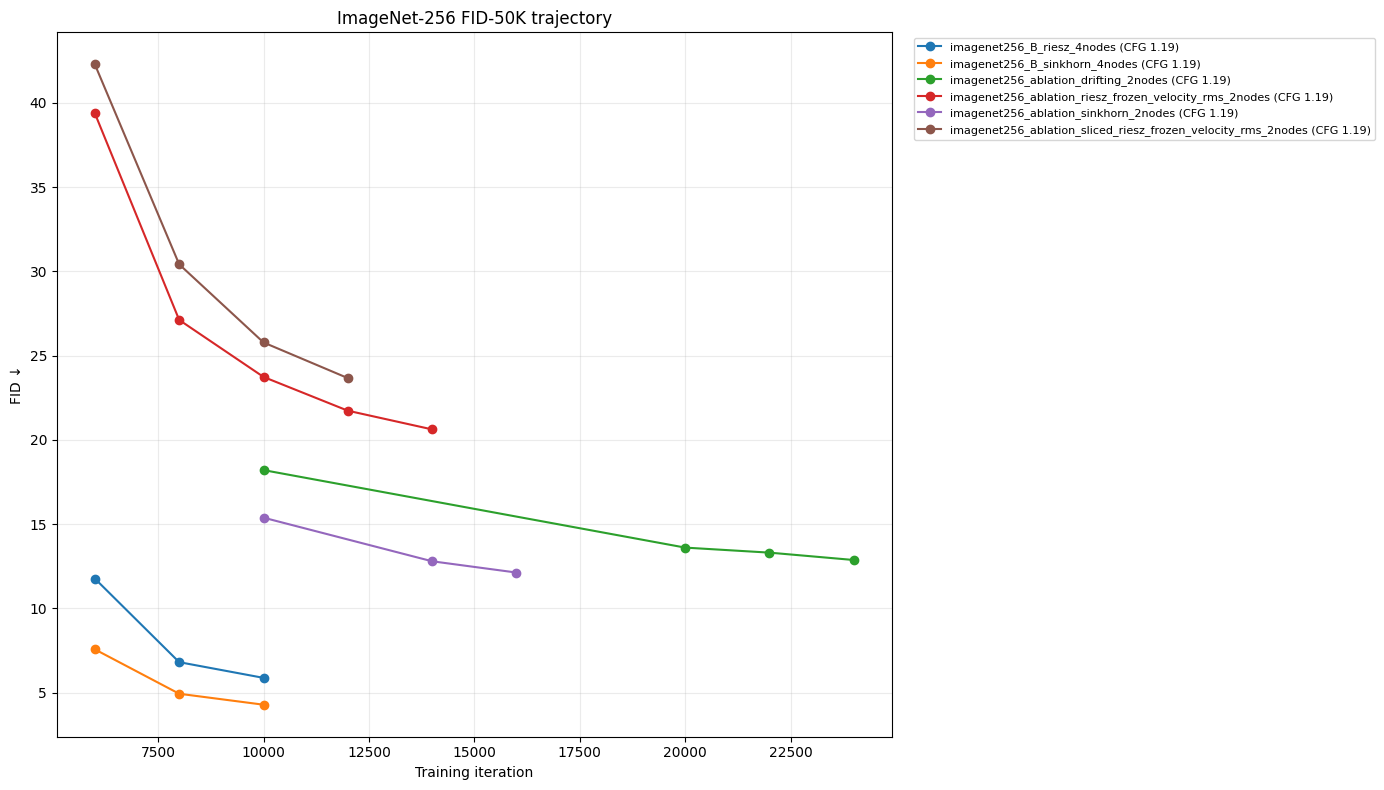

Saved /home/rc-chen1/riesz_flow_hudson/notebooks/fid_imagenet256_fid50k_scores.csv and /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet256/fid50k_trajectory.png


In [4]:
rows = []
for path in RESULTS_ROOT.rglob(f'fid{NUM_SAMPLES // 1000}k_step*_cfg*.json'):
    try:
        payload = json.loads(path.read_text())
        fid = float(payload['fid'])
        if not math.isfinite(fid): raise ValueError(f'non-finite FID: {fid}')
        if int(payload['step']) <= SKIP_THROUGH_STEP: continue
        rows.append({'run': Path(payload['ckpt']).expanduser().resolve().parent.parent.name, 'step': int(payload['step']), 'cfg_scale': float(payload['cfg_scale']), 'fid': fid, 'result': path})
    except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError) as exc:
        print(f'Ignoring invalid result {path}: {exc}')
results = pd.DataFrame(rows)
if results.empty:
    print('No matching cached results yet. Run the evaluation cell above.')
else:
    results = results.sort_values(['run', 'cfg_scale', 'step']).reset_index(drop=True)
    if results.duplicated(['run', 'step', 'cfg_scale']).any(): raise RuntimeError('Duplicate FID results found')
    trajectory_path = SCORE_CSV
    results[['run', 'step', 'cfg_scale', 'fid']].to_csv(trajectory_path, index=False)
    display(results[['run', 'step', 'cfg_scale', 'fid']])
    fig, ax = plt.subplots(figsize=(14, 8))
    for (run, cfg), group in results.groupby(['run', 'cfg_scale']):
        ax.plot(group.step, group.fid, marker='o', label=f'{run} (CFG {cfg:g})')
    ax.set(title=f'ImageNet-256 FID-{NUM_SAMPLES // 1000}K trajectory', xlabel='Training iteration', ylabel='FID ↓')
    ax.grid(alpha=.25); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8); fig.tight_layout()
    plot_path = RESULTS_ROOT / f'fid{NUM_SAMPLES // 1000}k_trajectory.png'
    fig.savefig(plot_path, dpi=180, bbox_inches='tight'); plt.show()
    print(f'Saved {trajectory_path} and {plot_path}')
